Exploratory Data Analysis

In this notebook I performed exploratory data analysis on the Telco Customer Churn dataset. The goal is to understand the data patterns, find missing values, detect outliers, analyze class imbalance and extract meaningful business insights that can guide the machine learning pipeline.

In [11]:
%matplotlib inline

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder


In [13]:
!git clone https://github.com/pradeepkumar2427/teleconnect-ml-assignment.git
import os
os.chdir("teleconnect-ml-assignment")
df=pd.read_csv("data/raw/Tele-Customer-Churn.csv")
print(df)


Cloning into 'teleconnect-ml-assignment'...
remote: Enumerating objects: 167, done.
remote: Counting objects: 100% (167/167), done.
remote: Compressing objects: 100% (147/147), done.
remote: Total 167 (delta 56), reused 75 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (167/167), 3.13 MiB | 11.38 MiB/s, done.
Resolving deltas: 100% (56/56), done.
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  480

In [14]:
df.describe() #It works on numeric columns and provides the value of min,max for each column
print("Information :",df.info())
print("Shape: ",df.shape)#It gives number of rows and number of columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [15]:
#To check all the missing values of each column
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [16]:
#In our dataset we dont have any missing columns, we seperate into numerical columns and categorical columns

df['TotalCharges'].dtype
#Here we have TotalCharges as object and some hidden values where set to NaN
#We should change TotalCharges to numeric as given from table
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges'].dtype
#For missing columns
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].median())

#Outliers: It is performed when value is beyond some range and mainly in numerical columns: tenure,TotalCharges and MonthlyCharges
#We chose MonthlyCharges because the values vary more and in tenure and Totalcharges they are in correct range



In [17]:
#Outliers value for MonthlyCharges
cols=['MonthlyCharges']
for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\nOutliers in {col}:")
    print(outliers[[col]])


Outliers in MonthlyCharges:
Empty DataFrame
Columns: [MonthlyCharges]
Index: []


## Class Imbalance Analysis
Churn distribution shows imbalanced classes.
No churn: ~73%, Churn: ~27%
This imbalance needs to be handled in preprocessing using SMOTE.

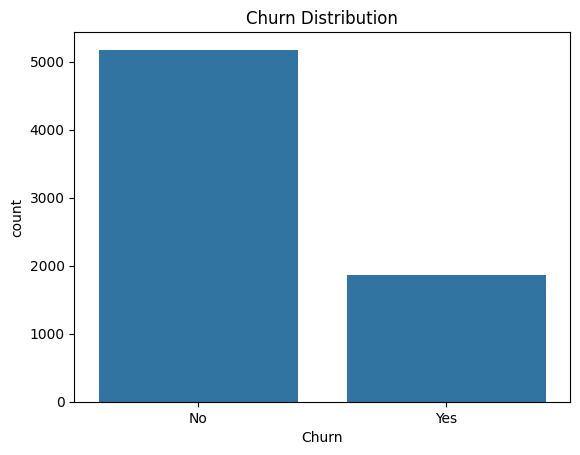

,proportion
Churn,
No,0.73463
Yes,0.26537


In [18]:
# In Churn column there are 2 classifications Yes or No and No has majority (Imbalanced Dataset)
#The target variable Churn shows class imbalance, with a significantly higher proportion of non-churned customers compared to churned customers.
#This imbalance may bias models toward predicting the majority class, and will be handled later using techniques like SMOTE or class weighting.
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

df['Churn'].value_counts(normalize=True)

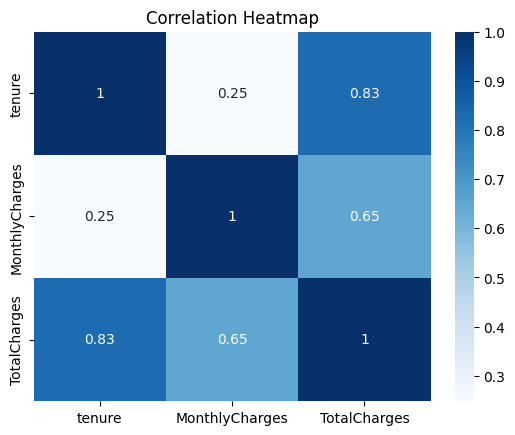

In [19]:
#TotalCharges is highly correlated with tenure and moderately correlated with MonthlyCharges,
#indicating that it is a derived feature influenced by both duration and monthly spending.
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

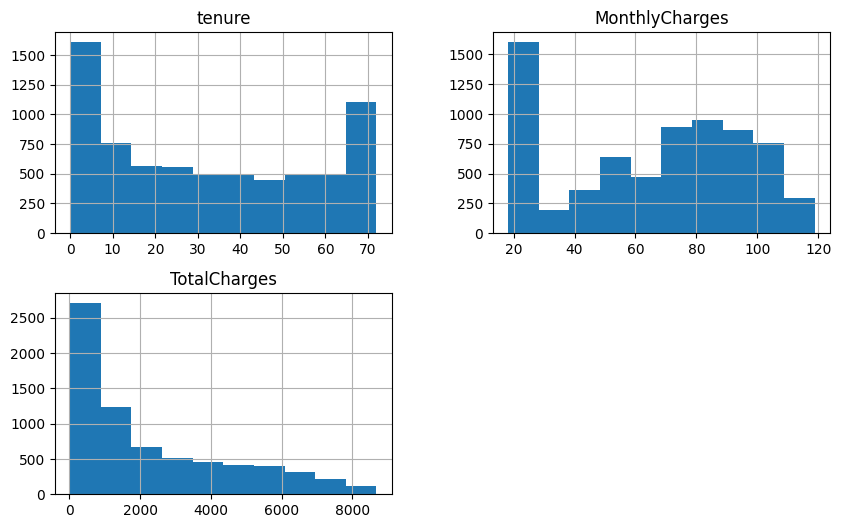

In [20]:
df[numeric_cols].hist(figsize=(10,6))
plt.show()

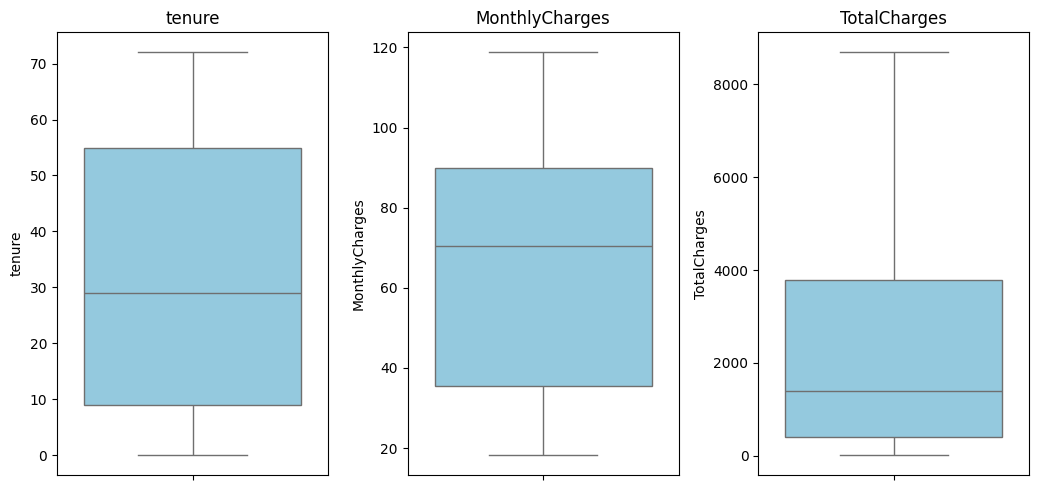

In [21]:
plt.figure(figsize=(14,5))
for i, col in enumerate(numeric_cols):
    plt.subplot(1,4,i+1)
    sns.boxplot(df[col], color = 'skyblue')
    plt.title(col)
plt.tight_layout()
plt.show()

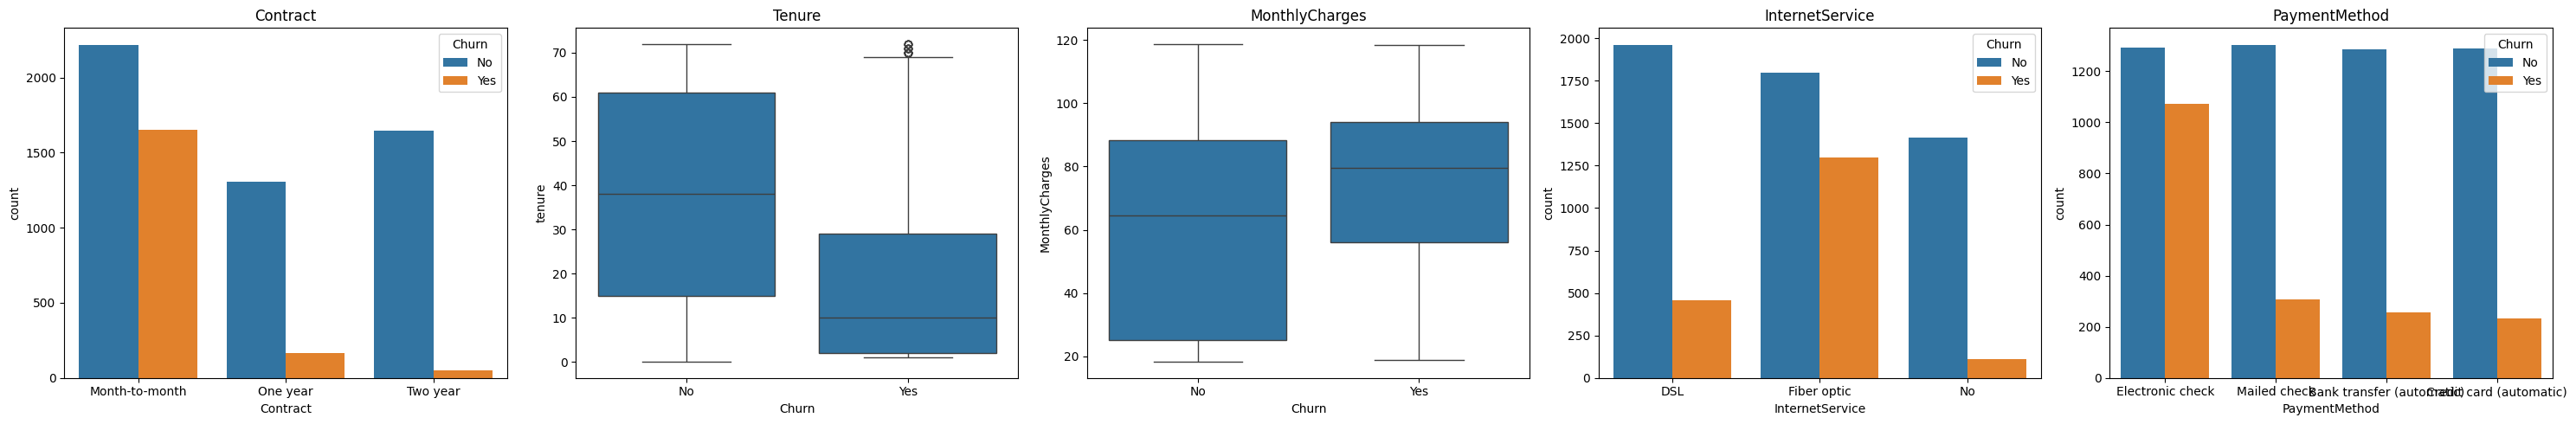

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(30,5))

# 1
plt.subplot(1,5,1)
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Contract')


# 2
plt.subplot(1,5,2)
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure')

# 3
plt.subplot(1,5,3)
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('MonthlyCharges')

# 4
plt.subplot(1,5,4)
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('InternetService')


# 5
plt.subplot(1,5,5)
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title('PaymentMethod')


plt.tight_layout()
plt.show()

Duplicate valuess should be removed as it cause some inaccuracy in our data

In [23]:
# Duplicates
print(df.columns)
categorical_col= df.select_dtypes(include=['object']).columns
print(categorical_col)

print("print all total no of duplicated value:",df.duplicated().sum())
df = df.drop_duplicates()
print("print all total no of duplicated value:",df.duplicated().sum())

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')
print all total no of duplicated value: 0
print all total no of duplicated value: 0


Business Insights those are learned from our data are

Insight 1 - Contract Type Matters Most
Customers on month-to-month contracts are churning at a much higher rate compared to those on one or two year contracts. This suggests that customers who have not committed long term feel less tied to the service. The company should focus on converting monthly customers to longer contracts by offering attractive discounts or added benefits.

Insight 2 - New Customers Need Special Attention
Customers who have been with the company for less than 12 months show the highest churn rate. This indicates that the onboarding experience may not be strong enough to retain new customers. A dedicated customer success program for the first year could significantly reduce churn.

Insight 3 - Price Sensitivity is Real
Customers paying higher monthly charges tend to churn more. This shows that customers are price sensitive and may be comparing with competitors. Offering loyalty discounts or better value bundles for long term customers could help retain them.

Insight 4 - Fiber Optic Service Needs Improvement
Despite being a premium service, fiber optic customers churn more than DSL customers. This could indicate quality issues or unmet expectations with the fiber service. Improving reliability and customer support for fiber customers is recommended.

Insight 5 - Security Services Build Loyalty
Customers without online security or tech support services tend to churn more. Adding these value added services increases customer stickiness and reduces the likelihood of switching to a competitor.